# Binary Model Training


## 1. Mount Google Drive

In [3]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [4]:
import pandas as pd

CSV_PATH = '/content/drive/MyDrive/DEPI Project/merged_dataset.csv'

df = pd.read_csv(CSV_PATH, low_memory=False)
print(f"Shape: {df.shape}")
print(f"Label dtype: {df['label'].dtype}")


Shape: (4525777, 63)
Label dtype: object


## 3. Delete Columns we don't need


In [5]:
cols_to_drop = [
    'No.', 'frame number',
    'IP Checksum', 'TCP Checksum', 'UDP Checksum', 'ICMP Checksum',
    'Info'
]
df = df.drop(columns=[c for c in cols_to_drop if c in df.columns])
print(f"Columns remaining: {len(df.columns)}")


Columns remaining: 56


In [6]:
final_drop_list = [
    'frame length', 'IP Length', 'TCP Length', 'UDP Length',
    'IP DSCP Field', 'IP Fragment Offset'
]
df = df.drop(columns=[c for c in final_drop_list if c in df.columns])
print(f"Columns remaining: {len(df.columns)}")


Columns remaining: 50


In [7]:
df = df.drop(columns=['IP Protocol'], errors='ignore')
df = df.drop_duplicates()
print(f"Shape after dedup: {df.shape}")


Shape after dedup: (4467762, 49)


## 4. HTTP features

In [8]:
df['is_http_request'] = df['HTTP Request Method'].notnull().astype(int)
df['is_suspicious_method'] = df['HTTP Request Method'].isin(
    ['POST', 'OPTIONS', 'PROPFIND']
).astype(int)

df['is_http_response'] = df['HTTP Response Code'].notnull().astype(int)
df['is_http_success'] = (df['HTTP Response Code'] == '200').astype(int)
df['is_http_error'] = df['HTTP Response Code'].str.startswith(('4', '5'), na=False).astype(int)
df['is_http_redirect'] = df['HTTP Response Code'].str.startswith('3', na=False).astype(int)

df = df.drop(columns=[c for c in ['HTTP Request Method', 'HTTP Response Code'] if c in df.columns])
print(f"Total columns now: {len(df.columns)}")


Total columns now: 53


In [9]:
df['is_attack_tool'] = df['HTTP User-Agent'].str.contains(
    r'sqlmap|ffuf|fuzz|apachebench|nmap|nikto|masscan|hydra|metasploit',
    case=False, na=False
).astype(int)

df['is_browser'] = df['HTTP User-Agent'].str.contains(
    r'mozilla|chrome|firefox|safari|edge', case=False, na=False
).astype(int)

df['is_script'] = df['HTTP User-Agent'].str.contains(
    r'python|curl|wget|requests|go-http', case=False, na=False
).astype(int)

df = df.drop(columns=['HTTP User-Agent'], errors='ignore')
print(f"Total columns now: {len(df.columns)}")


Total columns now: 55


In [10]:
uri = df['HTTP Request URI'].fillna('')
df['uri_has_params'] = uri.str.contains(r'\?', na=False).astype(int)
df = df.drop(columns=['HTTP Request URI', 'HTTP Full URI'], errors='ignore')

df['is_http_1_0'] = (df['HTTP Request Version'] == 'HTTP/1.0').astype(int)
df = df.drop(columns=['HTTP Request Version'], errors='ignore')

df['has_dns_query'] = df['DNS Query Name'].notnull().astype(int)
df = df.drop(columns=['DNS Query Name', 'DNS Query Type'], errors='ignore')

df['HTTP Content-Length'] = df['HTTP Content-Length'].fillna(0)
cols_to_drop_http = ['HTTP Connection', 'HTTP Content Type', 'HTTP Cookie',
                      'HTTP Referer', 'HTTP Host', 'HTTP Authorization', 'HTTP Location']
df = df.drop(columns=[c for c in cols_to_drop_http if c in df.columns])
print(f"Total columns now: {len(df.columns)}")


Total columns now: 46


## 5. UDP / ICMP / TCP handling

In [11]:
df['is_udp'] = df['UDP Destination Port'].notnull().astype(int)
df['UDP Destination Port'] = df['UDP Destination Port'].fillna(0).astype(int)
df['UDP Source Port'] = df['UDP Source Port'].fillna(0).astype(int)

df['is_icmp_packet'] = df['ICMP Type'].notna().astype(int)
df['ICMP Type'] = df['ICMP Type'].fillna(-1)

df['TCP Window Size'] = df['TCP Window Size'].fillna(0)

df['is_tcp_packet'] = df['TCP Flags'].notnull().astype(int)

tcp_flags = ['TCP SYN Flag', 'TCP ACK Flag', 'TCP RST Flag', 'TCP FIN Flag']
for flag in tcp_flags:
    df[flag] = pd.to_numeric(df[flag], errors='coerce').fillna(0).astype(int)

df['tcp_stream_exists'] = df['TCP Stream'].notnull().astype(int)

df['TCP Source Port'] = df['TCP Source Port'].fillna(-1)
df['TCP Destination Port'] = df['TCP Destination Port'].fillna(-1)

df['tcp_seq_exists'] = df['TCP Sequence Number'].notnull().astype(int)
df['tcp_ack_exists'] = df['TCP Acknowledgment Number'].notnull().astype(int)

# TCP Flags -> individual boolean flags, then drop the raw hex column
df['TCP Flags'] = df['TCP Flags'].apply(lambda x: int(x, 16) if isinstance(x, str) else 0)
df['tcp_syn'] = (df['TCP Flags'] & 0x002 != 0).astype(int)
df['tcp_ack'] = (df['TCP Flags'] & 0x010 != 0).astype(int)
df['tcp_fin'] = (df['TCP Flags'] & 0x001 != 0).astype(int)
df['tcp_rst'] = (df['TCP Flags'] & 0x004 != 0).astype(int)
df['tcp_psh'] = (df['TCP Flags'] & 0x008 != 0).astype(int)
df['tcp_urg'] = (df['TCP Flags'] & 0x020 != 0).astype(int)
df = df.drop(columns=['TCP Flags'])

print(f"Total columns now: {len(df.columns)}")


Total columns now: 57


## 6. IP-level features

In [12]:
df['has_ip_source'] = df['IP Source'].notnull().astype(int)
df['IP Source'] = df['IP Source'].fillna('0.0.0.0')

df['has_ip_dest'] = df['IP Destination'].notnull().astype(int)
df['IP Destination'] = df['IP Destination'].fillna('0.0.0.0')

df['IP Flags'] = df['IP Flags'].fillna('0').astype(str)
df['ip_flag_df'] = df['IP Flags'].str.contains('0x40', na=False).astype(int)
df['ip_flag_mf'] = df['IP Flags'].str.contains('0x20', na=False).astype(int)
df['ip_flag_none'] = df['IP Flags'].isin(['0x00', '0', '0x00,0x00']).astype(int)
df = df.drop(columns=['IP Flags'])

df['IP Version'] = df['IP Version'].fillna(4)
df['is_ipv6'] = (df['IP Version'] == 6).astype(int)

df['deltatime'] = df['deltatime'].fillna(0)
df['deltatime'] = df['deltatime'].astype(str).str.strip()
df['deltatime'] = pd.to_numeric(df['deltatime'], errors='coerce').fillna(0)

df['Length'] = df['Length'].astype(str).str.strip()
df['Length'] = pd.to_numeric(df['Length'], errors='coerce').fillna(0)

df['has_ttl'] = df['IP TTL'].notna().astype(int)
df['IP TTL'] = df['IP TTL'].astype(str).str.split(',').str[0]
df['IP TTL'] = pd.to_numeric(df['IP TTL'], errors='coerce').fillna(0)

print(f"Total columns now: {len(df.columns)}")


Total columns now: 63


In [13]:
cols_to_drop = [
    'Time', 'Frame Time', 'Frame Time (Epoch)',
    'Source', 'Destination',
    'Ethernet Source', 'Ethernet Destination',
    'IP Source', 'IP Destination',
    'IP Version', 'Frame Protocols'
]
df = df.drop(columns=[c for c in cols_to_drop if c in df.columns])
print(f"Total columns: {len(df.columns)}")


Total columns: 52


## 7. 🔴 (Feature Leakage Fix)


In [14]:
leak_features = ['TCP Stream', 'TCP Sequence Number',
                  'TCP Acknowledgment Number', 'TCP Destination Port','deltatime']

df = df.drop(columns=[c for c in leak_features if c in df.columns])

print(f"Columns remaining: {len(df.columns)}")
print(f"Confirmed dropped: {[c for c in leak_features if c not in df.columns]}")


Columns remaining: 47
Confirmed dropped: ['TCP Stream', 'TCP Sequence Number', 'TCP Acknowledgment Number', 'TCP Destination Port', 'deltatime']


## 8. convert Numeric columns

In [15]:
num_cols = [
    'TCP Source Port', 'TCP Window Size',
    'UDP Source Port', 'UDP Destination Port',
    'ICMP Type', 'HTTP Content-Length', 'IP TTL'
]

for col in num_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col].astype(str).str.strip(), errors='coerce').fillna(0)

print("Done!")
print(df[[c for c in num_cols if c in df.columns]].dtypes)


Done!
TCP Source Port         float64
TCP Window Size         float64
UDP Source Port           int64
UDP Destination Port      int64
ICMP Type               float64
HTTP Content-Length     float64
IP TTL                  float64
dtype: object


## 9. Train / Test Split

In [16]:
from sklearn.model_selection import train_test_split

df = df.sample(frac=1, random_state=42).reset_index(drop=True)

X = df.drop(columns=['label', 'is_attack'])
y_bin = df['is_attack'].astype(int)
y_multi = df['label'].astype(str)

X_train, X_test, y_train_bin, y_test_bin, y_train_multi, y_test_multi = train_test_split(
    X, y_bin, y_multi,
    test_size=0.2,
    random_state=42,
    stratify=y_bin
)

print(f"Split Done! Train: {X_train.shape} | Test: {X_test.shape}")
print(y_train_bin.value_counts())


Split Done! Train: (3574209, 45) | Test: (893553, 45)
is_attack
1    2566634
0    1007575
Name: count, dtype: int64


## 10. Protocol

In [17]:
from sklearn.preprocessing import LabelEncoder

top_protocols = df['Protocol'].value_counts().head(10).index.tolist()

X_train['Protocol'] = X_train['Protocol'].apply(lambda x: x if x in top_protocols else 'Other')
X_test['Protocol']  = X_test['Protocol'].apply(lambda x: x if x in top_protocols else 'Other')

le = LabelEncoder()
X_train['Protocol'] = le.fit_transform(X_train['Protocol'])
X_test['Protocol']  = le.transform(X_test['Protocol'])


In [18]:
obj_cols = X_train.select_dtypes(include='object').columns.tolist()
print(f"Object columns to drop: {obj_cols}")
X_train = X_train.drop(columns=obj_cols)
X_test  = X_test.drop(columns=obj_cols)
print("Done!")


Object columns to drop: ['Ethernet Type']
Done!


In [19]:
%pip install xgboost -q

In [20]:
spw = (y_train_bin == 0).sum() / (y_train_bin == 1).sum()
print(f'scale_pos_weight = {spw:.3f}')

from xgboost import XGBClassifier

model_binary_v1 = XGBClassifier(
    n_estimators=400, max_depth=6, learning_rate=0.05,
    scale_pos_weight=spw, subsample=0.8, colsample_bytree=0.8,
    eval_metric='auc', tree_method='hist', random_state=42, n_jobs=-1
)

X_train2, X_val2, y_train2, y_val2 = train_test_split(
    X_train, y_train_bin, test_size=0.1, random_state=42, stratify=y_train_bin
)

model_binary_v1.fit(X_train2, y_train2, eval_set=[(X_val2, y_val2)], verbose=50)

#الأرقام دي معناها إيه بالظبط
#AUC (Area Under Curve) بيقيس قدرة الموديل يفرّق بين Normal وAttack. المقياس من 0 لـ 1:
#
#0.5 = عشوائي تمامًا (زي رمي عملة)
#0.9+ = ممتاز
#0.98-0.99 = ممتاز جدًا (تقريبًا سقف الأداء العملي)
#
#يعني 0.98886 مش رقم واطي خالص — ده أداء قوي جدًا لموديل حقيق


#كتباهم عشان نفتكر واحنا بنراجع


scale_pos_weight = 0.393
[0]	validation_0-auc:0.90919
[50]	validation_0-auc:0.94839
[100]	validation_0-auc:0.95207
[150]	validation_0-auc:0.95839
[200]	validation_0-auc:0.96067
[250]	validation_0-auc:0.96160
[300]	validation_0-auc:0.96236
[350]	validation_0-auc:0.96285
[399]	validation_0-auc:0.96301


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='auc', feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.05, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=400,
              n_jobs=-1, num_parallel_tree=None, ...)

Train: 0.8511 | Test: 0.8518 | Diff: 0.0007
              precision    recall  f1-score   support

      Normal       0.66      0.96      0.79    251894
      Attack       0.98      0.81      0.89    641659

    accuracy                           0.85    893553
   macro avg       0.82      0.89      0.84    893553
weighted avg       0.89      0.85      0.86    893553



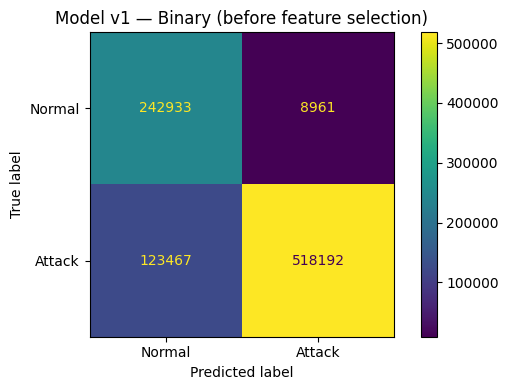

In [21]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

y_pred_bin = model_binary_v1.predict(X_test)
train_acc = accuracy_score(y_train2, model_binary_v1.predict(X_train2))
test_acc = accuracy_score(y_test_bin, y_pred_bin)
print(f'Train: {train_acc:.4f} | Test: {test_acc:.4f} | Diff: {abs(train_acc-test_acc):.4f}')
print(classification_report(y_test_bin, y_pred_bin, target_names=['Normal', 'Attack']))

cm = confusion_matrix(y_test_bin, y_pred_bin)
fig, ax = plt.subplots(figsize=(6, 4))
ConfusionMatrixDisplay(cm, display_labels=['Normal', 'Attack']).plot(ax=ax)
plt.title('Model v1 — Binary (before feature selection)')
plt.tight_layout()
plt.show()


## 12. Select Top 20 Feature


In [22]:
import pandas as pd

feat_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': model_binary_v1.feature_importances_
}).sort_values('Importance', ascending=False)

TOP_N = 20
selected_features = feat_df.head(TOP_N)['Feature'].tolist()
print(f"Selected ({len(selected_features)}): {selected_features}")


Selected (20): ['ip_flag_df', 'ip_flag_none', 'is_http_1_0', 'tcp_syn', 'is_http_request', 'tcp_rst', 'Length', 'tcp_psh', 'TCP Window Size', 'is_script', 'has_dns_query', 'is_browser', 'TCP Source Port', 'is_attack_tool', 'HTTP Content-Length', 'tcp_stream_exists', 'is_http_response', 'Protocol', 'is_http_success', 'uri_has_params']


/tmp/ipykernel_9401/1099523186.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feat_df.head(TOP_N), palette='viridis')


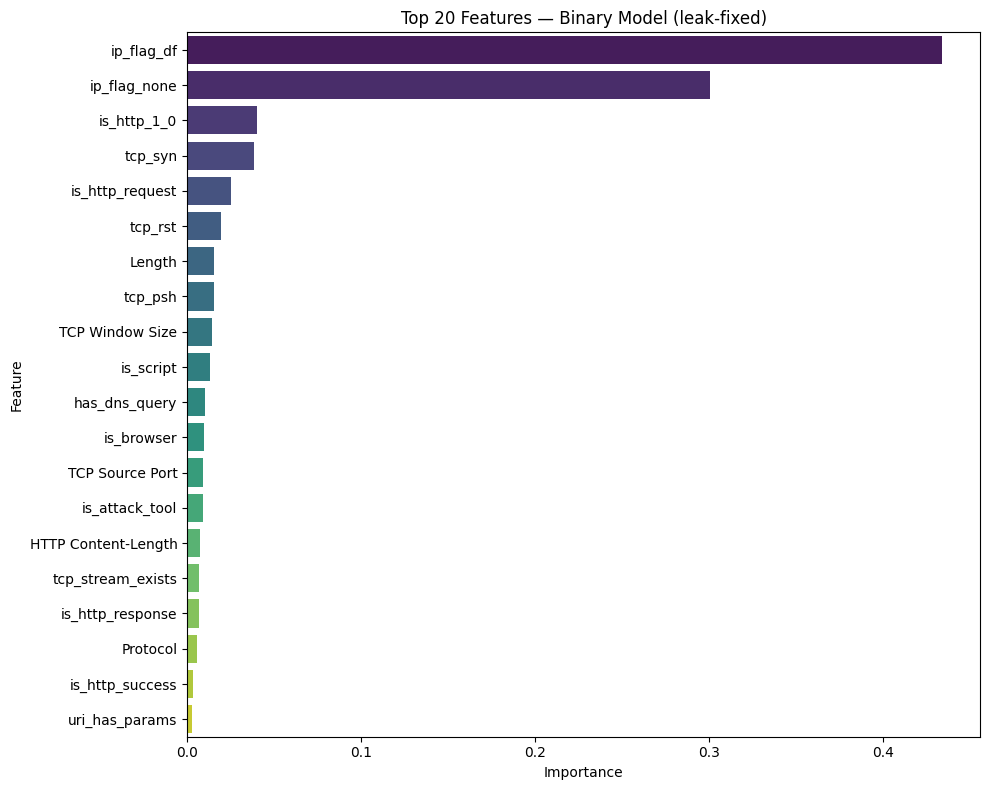

In [23]:
import seaborn as sns
plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Feature', data=feat_df.head(TOP_N), palette='viridis')
plt.title(f'Top {TOP_N} Features — Binary Model (leak-fixed)')
plt.tight_layout()
plt.show()


## 13. Train Model


In [24]:
X_train_sel_bin = X_train[selected_features]
X_test_sel_bin  = X_test[selected_features]

X_train22, X_val22, y_train22, y_val22 = train_test_split(
    X_train_sel_bin, y_train_bin, test_size=0.1, random_state=42, stratify=y_train_bin
)

from xgboost import XGBClassifier

model_binary = XGBClassifier(
    n_estimators=400, max_depth=6, learning_rate=0.05,
    scale_pos_weight=spw, subsample=0.8, colsample_bytree=0.8,
    eval_metric='auc', tree_method='hist', random_state=42, n_jobs=-1
)

model_binary.fit(X_train22, y_train22, eval_set=[(X_val22, y_val22)], verbose=50)


[0]	validation_0-auc:0.91583
[50]	validation_0-auc:0.94994
[100]	validation_0-auc:0.95347
[150]	validation_0-auc:0.95851
[200]	validation_0-auc:0.96045
[250]	validation_0-auc:0.96124
[300]	validation_0-auc:0.96178
[350]	validation_0-auc:0.96210
[399]	validation_0-auc:0.96238


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='auc', feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.05, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=400,
              n_jobs=-1, num_parallel_tree=None, ...)

Train: 0.8449 | Test: 0.8454 | Diff: 0.0004
              precision    recall  f1-score   support

      Normal       0.65      0.97      0.78    251894
      Attack       0.99      0.80      0.88    641659

    accuracy                           0.85    893553
   macro avg       0.82      0.88      0.83    893553
weighted avg       0.89      0.85      0.85    893553



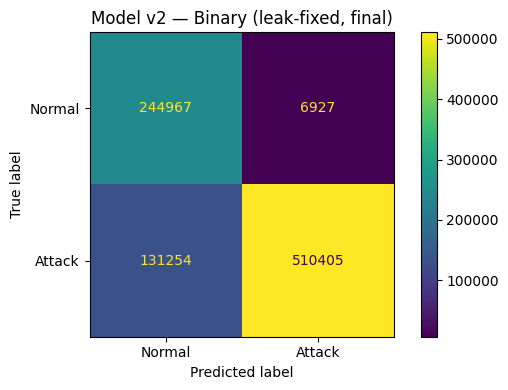

In [25]:
y_pred_bin = model_binary.predict(X_test_sel_bin)
train_acc = accuracy_score(y_train22, model_binary.predict(X_train22))
test_acc = accuracy_score(y_test_bin, y_pred_bin)
print(f'Train: {train_acc:.4f} | Test: {test_acc:.4f} | Diff: {abs(train_acc-test_acc):.4f}')
print(classification_report(y_test_bin, y_pred_bin, target_names=['Normal', 'Attack']))

cm = confusion_matrix(y_test_bin, y_pred_bin)
fig, ax = plt.subplots(figsize=(6, 4))
ConfusionMatrixDisplay(cm, display_labels=['Normal', 'Attack']).plot(ax=ax)
plt.title('Model v2 — Binary (leak-fixed, final)')
plt.tight_layout()
plt.show()


In [26]:
import os
import joblib

SAVE_DIR = '/content/drive/MyDrive/DEPI Project/Models'
os.makedirs(SAVE_DIR, exist_ok=True)


model_binary.save_model(os.path.join(SAVE_DIR, 'model_binary_v4.json'))

joblib.dump(selected_features, os.path.join(SAVE_DIR, 'feature_names_binary_v4.pkl'))
joblib.dump(le, os.path.join(SAVE_DIR, 'label_encoder_protocol_v4.pkl'))
joblib.dump(top_protocols, os.path.join(SAVE_DIR, 'top_protocols_v4.pkl'))

print("Done")

Done
